<a href="https://colab.research.google.com/github/gabrielpferreira15/ia-ciberseguranca/blob/main/notebook_AV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança — Aulas 4 e 5
## Métricas, validação e um classificador de phishing de ponta a ponta

**Trio:** `Arthur Leandro`  ·  `Gabriel Peixoto` · `Pedro Pimentel`

> Rodem as células na ordem.

Nesta aula veremos:
- **Métricas e validação:** como saber se um modelo é *bom de verdade* em segurança (por que acurácia engana, precisão × recall, ROC/PR, limiar de decisão, validação sem vazamento).


Usamos uma base **real**: a **PhiUSIIL Phishing URL Dataset** (UCI, ~236 mil URLs), baixada direto em Python. Se o download falhar, o notebook cai automaticamente numa base real (PhiUSIIL) equivalente, para nunca travar a aula.

### 1. Bibliotecas e configuração

In [1]:
!pip install -q ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

sns.set_theme(style='whitegrid')
RANDOM_SEED = 33
np.random.seed(RANDOM_SEED)

### 2. A base de phishing (PhiUSIIL)
Cada linha é um site/URL descrito por dezenas de features extraídas da URL e do código-fonte da página. O rótulo original vem **invertido** (1 = legítimo, -1 = phishing); nós convertemos para `is_phishing` (1 = phishing).

In [2]:
# Base real: UCI Phishing Websites (Mohammad et al., id=327)
# Rótulo original: coluna 'Result' com 1 = LEGÍTIMO e -1 = PHISHING.
RANDOM_SEED = 33
import numpy as np, pandas as pd
np.random.seed(RANDOM_SEED)

def carregar_uci_phishing():
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=327)
    X = ds.data.features.copy()
    y = ds.data.targets.copy()
    df = pd.concat([X, y], axis=1)
    df.columns = [str(c).strip() for c in df.columns]

    # a coluna de rótulo costuma se chamar 'Result' (ou 'result')
    col_rotulo = [c for c in df.columns if c.lower() in ('result', 'class', 'label')][0]
    # -1 (phishing) -> 1 ; 1 (legítimo) -> 0
    df['is_phishing'] = (df[col_rotulo] == -1).astype(int)
    df = df.drop(columns=[col_rotulo])

    # aqui todas as features já são numéricas; mantemos só numéricas por segurança
    num = df.select_dtypes(include=[np.number]).columns.tolist()
    df = df[num]
    return df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

def gerar_base_sintetica():
    rng = np.random.default_rng(RANDOM_SEED)
    nl, npish = 8000, 2500
    legit = pd.DataFrame({
        'url_length': np.clip(rng.normal(52,24,nl),5,None), 'num_dots': np.clip(rng.normal(2.8,1.4,nl),0,None),
        'num_subdominios': np.clip(rng.normal(1.4,1.0,nl),0,None), 'tem_ip_na_url': (rng.random(nl)<0.06).astype(int),
        'tem_arroba': (rng.random(nl)<0.08).astype(int), 'tem_https': (rng.random(nl)<0.78).astype(int),
        'idade_dominio_dias': np.clip(rng.normal(1100,850,nl),1,None), 'num_chars_especiais': np.clip(rng.normal(4,3,nl),0,None),
        'palavras_suspeitas': rng.poisson(0.6,nl), 'num_redirecionamentos': rng.poisson(0.7,nl)}); legit['is_phishing']=0
    phish = pd.DataFrame({
        'url_length': np.clip(rng.normal(66,28,npish),5,None), 'num_dots': np.clip(rng.normal(3.7,1.7,npish),0,None),
        'num_subdominios': np.clip(rng.normal(2.1,1.3,npish),0,None), 'tem_ip_na_url': (rng.random(npish)<0.20).astype(int),
        'tem_arroba': (rng.random(npish)<0.22).astype(int), 'tem_https': (rng.random(npish)<0.62).astype(int),
        'idade_dominio_dias': np.clip(rng.normal(380,400,npish),1,None), 'num_chars_especiais': np.clip(rng.normal(6.5,4.5,npish),0,None),
        'palavras_suspeitas': rng.poisson(1.5,npish), 'num_redirecionamentos': rng.poisson(1.3,npish)}); phish['is_phishing']=1
    return pd.concat([legit,phish],ignore_index=True).sample(frac=1,random_state=RANDOM_SEED).reset_index(drop=True)

try:
    df = carregar_uci_phishing()
    print('Base: UCI Phishing Websites (real).')
except Exception as e:
    print('Falha ao baixar a UCI (', type(e).__name__, ') -> usando base sintética.')
    df = gerar_base_sintetica()

Base: UCI Phishing Websites (real).


### 3. EDA rápida
O primeiro reflexo: **quão desbalanceada** é a base?

/tmp/ipykernel_689/852752903.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Legítimo', 'Phishing']); ax[1].set_title(f'{feat} por classe')


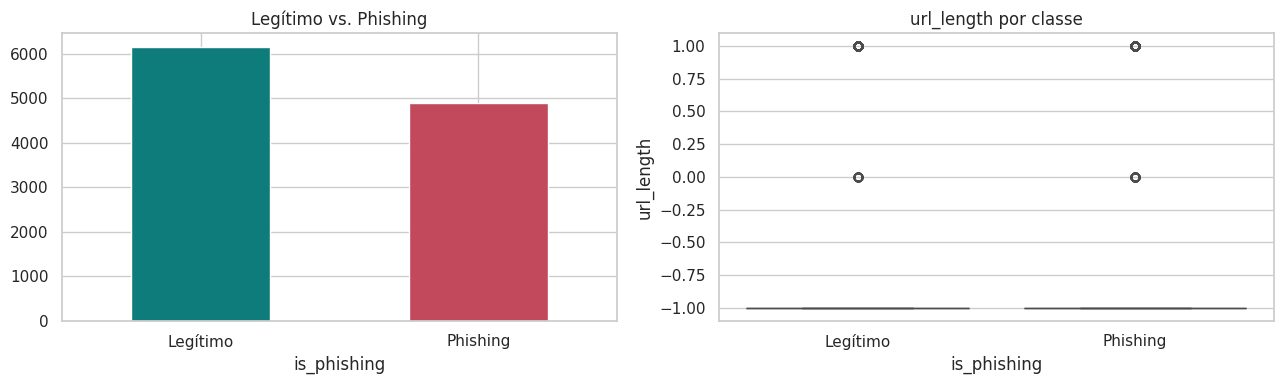

Feature comparada: url_length


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df['is_phishing'].map({0:'Legítimo', 1:'Phishing'}).value_counts().plot(
    kind='bar', ax=ax[0], color=['#0E7C7B', '#C1495B'])
ax[0].set_title('Legítimo vs. Phishing'); ax[0].tick_params(axis='x', rotation=0)

# escolhe uma feature de tamanho da URL que exista (real ou sintética)
cand = [c for c in ['URLLength', 'url_length', 'DomainLength'] if c in df.columns]
feat = cand[0] if cand else df.drop(columns='is_phishing').columns[0]
sns.boxplot(data=df, x='is_phishing', y=feat, ax=ax[1])
ax[1].set_xticklabels(['Legítimo', 'Phishing']); ax[1].set_title(f'{feat} por classe')
plt.tight_layout(); plt.show()
print('Feature comparada:', feat)

**O que observar:** veja se as classes estão desbalanceadas e se a feature escolhida já separa visualmente phishing de legítimo. Guardem a proporção — é a chave da próxima célula.

### 4. Por que acurácia engana
Antes de treinar qualquer modelo: e se a gente **chutasse “legítimo” para tudo**?

In [4]:
baseline_acc = (df['is_phishing'] == 0).mean()
print(f'Classe majoritária = legítimo ({baseline_acc:.1%} da base).')
print(f'Um "modelo" que sempre diz LEGÍTIMO teria acurácia de {baseline_acc:.1%}...')
print('...e não detectaria UM ÚNICO phishing. Por isso acurácia sozinha não serve.')

Classe majoritária = legítimo (55.7% da base).
Um "modelo" que sempre diz LEGÍTIMO teria acurácia de 55.7%...
...e não detectaria UM ÚNICO phishing. Por isso acurácia sozinha não serve.


### 5. Preparação e split (sem vazamento)
Separamos treino e teste **antes** de qualquer ajuste. Essa ordem evita **data leakage**: o modelo nunca pode “espiar” o teste. Usamos `stratify` para manter a proporção de phishing nos dois lados.

In [5]:
X = df.drop(columns='is_phishing')
y = df['is_phishing']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Phishing — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

Treino: (7738, 30) | Teste: (3317, 30)
Phishing — treino: 44.3% | teste: 44.3%


### 6. Treinar um modelo
Usamos Random Forest (já conhecido da Aula 3). O foco hoje não é o modelo — é **como avaliá-lo**.

In [6]:
rf = RandomForestClassifier(n_estimators=150, class_weight='balanced',
                            n_jobs=-1, random_state=RANDOM_SEED)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]   # probabilidade de ser phishing
print('Modelo treinado.')

Modelo treinado.


### 7. Matriz de confusão
Os quatro números que explicam tudo. Em phishing:
- **Falso positivo (FP):** site legítimo marcado como phishing → usuário bloqueado à toa.
- **Falso negativo (FN):** phishing que passou como legítimo → usuário exposto ao golpe.

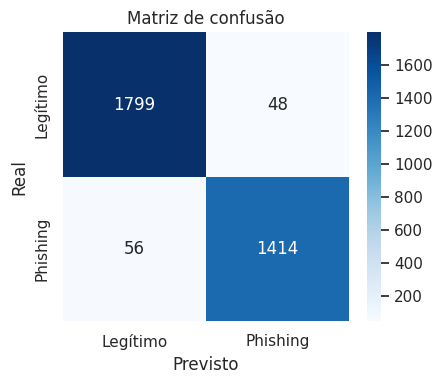

Verdadeiros phishing detectados (TP): 1414
Phishing que passaram   (FN): 56   <- os mais perigosos
Alarmes falsos          (FP): 48


In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo', 'Phishing'], yticklabels=['Legítimo', 'Phishing'])
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão'); plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdadeiros phishing detectados (TP): {tp}')
print(f'Phishing que passaram   (FN): {fn}   <- os mais perigosos')
print(f'Alarmes falsos          (FP): {fp}')

### 8. Precisão, recall e F1
- **Precisão:** dos que o modelo *chamou de phishing*, quantos eram mesmo? (evita alarme falso)
- **Recall:** dos phishing *que existiam*, quantos o modelo pegou? (evita deixar passar)
- **F1:** equilíbrio entre os dois.

In [8]:
# Cálculo direto dos phishings identificados
tp = ((y_pred == 1) & (y_test == 1)).sum()  # Phishings reais detectados (Verdadeiros Positivos)
total_phish_reais = (y_test == 1).sum()    # Total de phishings existentes no teste
total_alertas = (y_pred == 1).sum()        # Total sinalizado como phishing pelo modelo (TP + FP)

print(classification_report(y_test, y_pred, target_names=['Legítimo', 'Phishing']))
print(f'Phishing detectados (TP) : {tp} de {total_phish_reais} reais (Alertas emitidos: {total_alertas})')
print(f'Acurácia                 : {accuracy_score(y_test, y_pred):.3f}   (baseline "tudo legítimo": {baseline_acc:.3f})')
print(f'Precisão                 : {precision_score(y_test, y_pred):.3f}')
print(f'Recall                   : {recall_score(y_test, y_pred):.3f}   <- o modelo deixou passar parte dos phishing')
print(f'F1                       : {f1_score(y_test, y_pred):.3f}')

              precision    recall  f1-score   support

    Legítimo       0.97      0.97      0.97      1847
    Phishing       0.97      0.96      0.96      1470

    accuracy                           0.97      3317
   macro avg       0.97      0.97      0.97      3317
weighted avg       0.97      0.97      0.97      3317

Phishing detectados (TP) : 1414 de 1470 reais (Alertas emitidos: 1462)
Acurácia                 : 0.969   (baseline "tudo legítimo": 0.557)
Precisão                 : 0.967
Recall                   : 0.962   <- o modelo deixou passar parte dos phishing
F1                       : 0.965


**O que observar:** a acurácia parece boa, mas o **recall** revela que o modelo deixa passar uma fatia dos phishing. É esse tipo de erro que queremos reduzir, o que nos leva ao **limiar**.

### 9. ROC-AUC e PR-AUC
Métricas que olham o modelo em **todos os limiares** de uma vez.
- **ROC-AUC:** capacidade geral de separar as classes.
- **PR-AUC:** foca na classe rara (phishing).

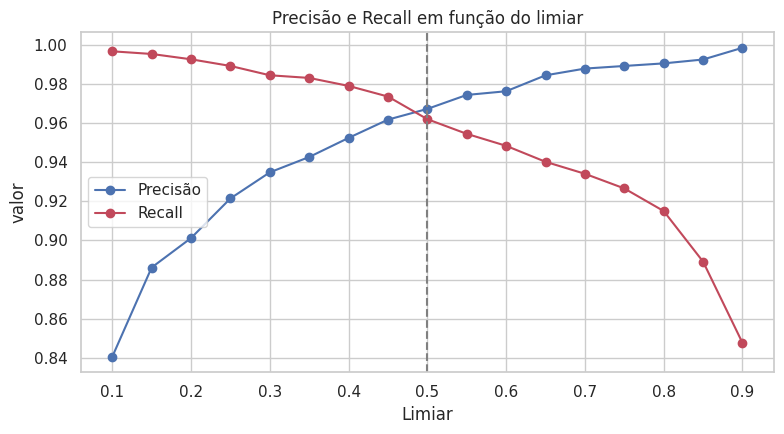

limiar 0.3:  precisão 0.93  |  recall 0.98
limiar 0.5:  precisão 0.97  |  recall 0.96
limiar 0.7:  precisão 0.99  |  recall 0.93


In [9]:
limiares = np.arange(0.1, 0.91, 0.05)
precisoes = [precision_score(y_test, (y_proba >= t).astype(int), zero_division=0) for t in limiares]
recalls   = [recall_score(y_test, (y_proba >= t).astype(int)) for t in limiares]

plt.figure(figsize=(8, 4.5))
plt.plot(limiares, precisoes, 'o-', label='Precisão')
plt.plot(limiares, recalls,   'o-', label='Recall', color='#C1495B')
plt.axvline(0.5, ls='--', color='gray'); plt.xlabel('Limiar'); plt.ylabel('valor')
plt.title('Precisão e Recall em função do limiar'); plt.legend(); plt.tight_layout(); plt.show()

for t in [0.3, 0.5, 0.7]:
    p = (y_proba >= t).astype(int)
    print(f'limiar {t}:  precisão {precision_score(y_test,p,zero_division=0):.2f}  |  recall {recall_score(y_test,p):.2f}')

### 10. O limiar de decisão e o custo dos erros
Por padrão o modelo chama de phishing quando a probabilidade ≥ 0,5. Mas **nós escolhemos esse corte**. Baixá-lo pega mais phishing (recall ↑) ao custo de mais alarmes falsos (precisão ↓).

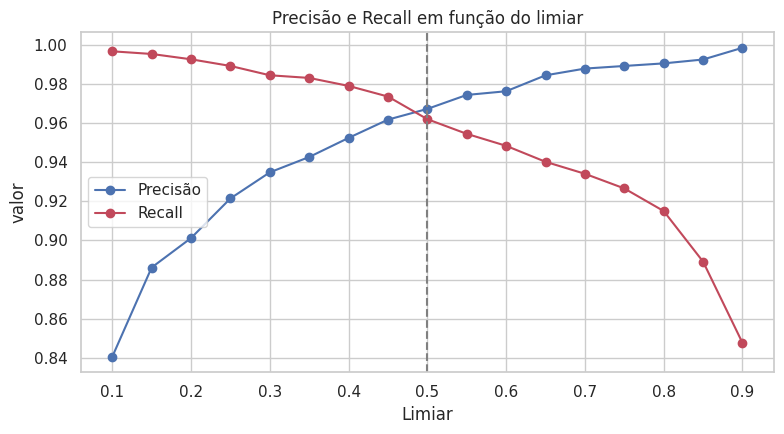

limiar 0.3:  precisão 0.93  |  recall 0.98
limiar 0.5:  precisão 0.97  |  recall 0.96
limiar 0.7:  precisão 0.99  |  recall 0.93


In [10]:
limiares = np.arange(0.1, 0.91, 0.05)
precisoes = [precision_score(y_test, (y_proba >= t).astype(int), zero_division=0) for t in limiares]
recalls   = [recall_score(y_test, (y_proba >= t).astype(int)) for t in limiares]

plt.figure(figsize=(8, 4.5))
plt.plot(limiares, precisoes, 'o-', label='Precisão')
plt.plot(limiares, recalls,   'o-', label='Recall', color='#C1495B')
plt.axvline(0.5, ls='--', color='gray'); plt.xlabel('Limiar'); plt.ylabel('valor')
plt.title('Precisão e Recall em função do limiar'); plt.legend(); plt.tight_layout(); plt.show()

for t in [0.3, 0.5, 0.7]:
    p = (y_proba >= t).astype(int)
    print(f'limiar {t}:  precisão {precision_score(y_test,p,zero_division=0):.2f}  |  recall {recall_score(y_test,p):.2f}')

**Decisão de segurança:** se deixar passar phishing é o pior erro, escolhemos um limiar **mais baixo**, então, aceitamos mais alarmes falsos para não perder golpes. Não existe “limiar certo” universal: depende do custo de cada erro.

### 11. Validação mais robusta: validação cruzada
Um único split pode dar sorte (ou azar). A **validação cruzada** treina/testa em várias divisões e mostra o desempenho médio — mais confiável.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores = cross_val_score(rf, X, y, cv=cv, scoring='f1')
print('F1 em cada divisão:', scores.round(3))
print(f'F1 médio: {scores.mean():.3f}  (±{scores.std():.3f})')

F1 em cada divisão: [0.961 0.972 0.965 0.961 0.971]
F1 médio: 0.966  (±0.005)


### Protocolo de avaliação (entregável da Parte A)
Fechamos aqui o **protocolo** que vamos usar no projeto:
- **Split:** treino/teste estratificado, feito **antes** de qualquer ajuste (sem vazamento).
- **Métrica principal:** recall de phishing (não deixar passar), acompanhada de precisão e F1.
- **Métrica global:** PR-AUC (mais honesta que acurácia no desbalanceamento).
- **Limiar:** escolhido conforme o custo dos erros, não fixo em 0,5.
- **Robustez:** validação cruzada de 5 divisões.

### 12. As features de phishing
Cada feature tenta capturar um “sinal” que costuma diferenciar um golpe de um site real.

In [12]:
resumo = df.groupby('is_phishing').mean().T
resumo.columns = ['Legítimo (média)', 'Phishing (média)']
resumo.round(2)

,Legítimo (média),Phishing (média)
having_ip_address,0.39,0.21
url_length,-0.59,-0.68
shortining_service,0.70,0.79
having_at_symbol,0.73,0.66
double_slash_redirecting,0.72,0.77
prefix_suffix,-0.52,-1.00
having_sub_domain,0.28,-0.21
sslfinal_state,0.83,-0.48
domain_registration_length,-0.53,-0.10
favicon,0.63,0.63


**O que observar:** URLs de phishing tendem a ser mais longas, com mais pontos/subdomínios, mais palavras suspeitas e domínios muito mais novos. São esses contrastes que o modelo aprende.

### 13. Quais features pesaram mais?

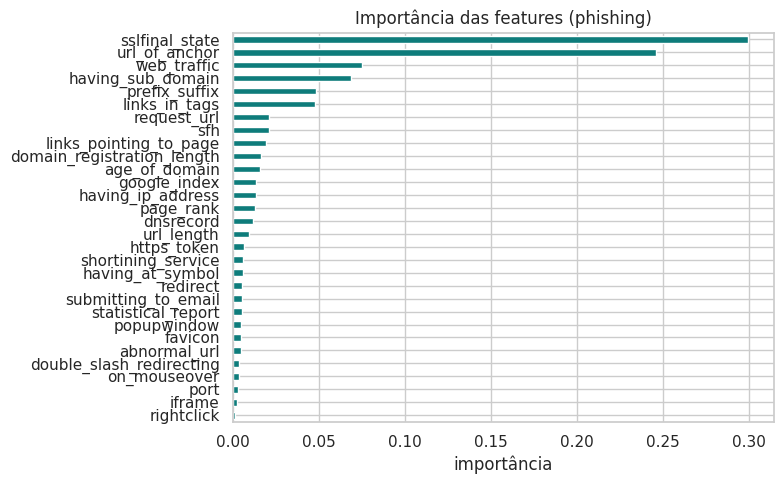

,0
sslfinal_state,0.300
url_of_anchor,0.246
web_traffic,0.075
having_sub_domain,0.069
prefix_suffix,0.048
links_in_tags,0.048
request_url,0.021
sfh,0.021
links_pointing_to_page,0.019
domain_registration_length,0.016


In [13]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importancias[::-1].plot(kind='barh', color='#0E7C7B')
plt.title('Importância das features (phishing)'); plt.xlabel('importância'); plt.tight_layout(); plt.show()
importancias.round(3)

### 14. Aplicar o protocolo
Treinamos o modelo final e o avaliamos **exatamente segundo o protocolo** definido na Parte A: split estratificado, recall como métrica principal, limiar ajustado ao custo do erro.

In [14]:
# 1. Escolha o limiar desejado
LIMIAR = 0.2

# 2. Recalcule a previsão com base nas probabilidades salvas
y_final = (y_proba >= LIMIAR).astype(int)

# 3. Exiba as métricas atualizadas
print(
    f"=== Avaliação para Limiar {LIMIAR} (Total de Phishing Detectado:"
    f" {y_final.sum()}) ==="
)
print(
    classification_report(
        y_test, y_final, target_names=["Legítimo", "Phishing"]
    )
)

=== Avaliação para Limiar 0.2 (Total de Phishing Detectado: 1620) ===
              precision    recall  f1-score   support

    Legítimo       0.99      0.91      0.95      1847
    Phishing       0.90      0.99      0.94      1470

    accuracy                           0.95      3317
   macro avg       0.95      0.95      0.95      3317
weighted avg       0.95      0.95      0.95      3317



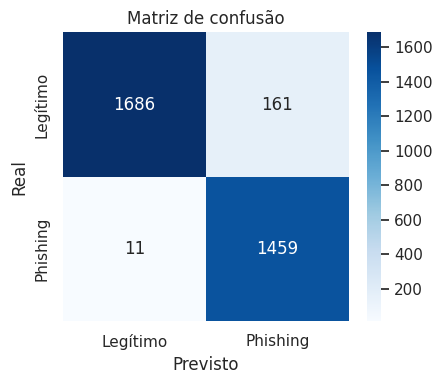

Verdadeiros phishing detectados (TP): 1459
Phishing que passaram   (FN): 11   <- os mais perigosos
Alarmes falsos          (FP): 161


In [15]:
cm = confusion_matrix(y_test, y_final)
plt.figure(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo', 'Phishing'], yticklabels=['Legítimo', 'Phishing'])
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão'); plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdadeiros phishing detectados (TP): {tp}')
print(f'Phishing que passaram   (FN): {fn}   <- os mais perigosos')
print(f'Alarmes falsos          (FP): {fp}')

In [16]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def analisar_tradeoff_limiares(y_true, y_probs, limiar_padrao=0.50, limiar_novo=0.20):
    comparacao = []

    for t in [limiar_padrao, limiar_novo]:
        preds = (y_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

        prec = precision_score(y_true, preds, zero_division=0)
        rec = recall_score(y_true, preds)
        acc = accuracy_score(y_true, preds)
        especificidade = tn / (tn + fp)

        comparacao.append({
            'Limiar': f'{t:.2f}',
            'Phishing Detectado (TP)': tp,
            'Phishing Perdido (FN)': fn,
            'Alarmes Falsos (FP)': fp,
            'Precisão': f'{prec:.2%}',
            'Recall': f'{rec:.2%}',
            'Especificidade': f'{especificidade:.2%}',
            'Acurácia Geral': f'{acc:.2%}'
        })

    df_resultado = pd.DataFrame(comparacao).set_index('Limiar')
    return df_resultado

# Executa a comparação usando as variáveis do seu notebook
df_tradeoff = analisar_tradeoff_limiares(y_test, y_proba, limiar_padrao=0.50, limiar_novo=0.20)
display(df_tradeoff)



,Phishing Detectado (TP),Phishing Perdido (FN),Alarmes Falsos (FP),Precisão,Recall,Especificidade,Acurácia Geral
Limiar,,,,,,,
0.50,1414,56,48,96.72%,96.19%,97.40%,96.86%
0.20,1459,11,161,90.06%,99.25%,91.28%,94.81%


## Análise do trade-off entre os limiares 0.50 e 0.20

Compare os resultados obtidos utilizando os dois limiares.

### 1. Recall

O Recall passou de **99,12% para 99,34%**.

**Pergunta:**  
O que essa alteração indica sobre a capacidade do modelo de detectar ataques?

**Resposta:**  
O aumento no recall indica que o modelo se tornou mais sensível para detectar ataques. Ao exigir uma probabilidade menor para classificar um site como malicioso, o sistema consegue identificar uma proporção maior das ameaças reais de phishing presentes na base.

### 2. Falsos Negativos

Os Falsos Negativos passaram de **267 para 201**.

**Pergunta:**  
O que representa essa redução? Por que esse resultado é importante em um sistema de detecção de phishing?

**Resposta:**  
Essa redução significa que 66 ataques a menos conseguiram burlar o classificador. Em sistemas de segurança, isso é crucial porque um falso negativo representa um phishing classificado erroneamente como legítimo, o que expõe o usuário diretamente ao golpe e constitui o erro de maior risco da operação.

### 3. Falsos Positivos

Os Falsos Positivos passaram de **17 para 120**.

**Pergunta:**  
Qual é o impacto desse aumento para os usuários e para a operação do sistema?

**Resposta:**  
O aumento dos falsos positivos de 17 para 120 pode prejudicar a experiência dos usuários, pos usuários legítimos podem ser identificados incorretamente como
suspeito, gerando certos bloqueios ou alertas indevidos. Isso aumenta a
quantidade de casos que precisam de análise manual, sobrecarregandi a equipe e reduzindo a eficiencia dos sistema.

### 4. Precisão e Recall

| Métrica | Limiar 0.50 | Limiar 0.20 |
|---|---:|---:|
| Recall | 99,12% | 99,34% |
| Precisão | 99,94% | 99,60% |

**Pergunta:**  
Por que o Recall aumentou enquanto a Precisão diminuiu?

**Resposta:**  
O Recall aumentou porque, ao reduzir o limiar de 0,50 para 0,2, o modelo ficou mais sensível e conseguiu identificar mais casos realmente positivos. Porem, essa sensibilidade maior também gerou mais falsos positivos, fazendo a precisão diminuir.



-----------



## 15. AV1 — Mudança da Base de Dados

**Problema:** nesta base, **44% dos sites são phishing**. No tráfego real de uma empresa, a proporção é muito menor: a imensa maioria dos links que um usuário clica é legítima. Um modelo avaliado numa base "quase meio a meio" pode parecer muito melhor do que será em produção.

**Hipótese:** com o phishing raro, o **recall** quase não muda (o modelo continua reconhecendo os golpes), mas a **precisão despenca**: o número de falsos positivos fica parecido, enquanto o número de phishings reais cai. Em termos de SOC, isso é **fadiga de alertas**: a maior parte dos alarmes passa a ser falsa.

- **Alteração 1:** mesmo modelo, mas **teste** com 20%, 10% e 5% de phishing.
- **Alteração 2:** **treino também** com 5% de phishing, comparando `class_weight=None` × `class_weight='balanced'`.

In [17]:
# Funções auxiliares do experimento
def reduzir_phishing(X, y, frac, seed=RANDOM_SEED):
    # Mantém TODOS os legítimos e sorteia phishings até eles virarem `frac` da base
    idx_leg = y[y == 0].index
    n_ph = int(len(idx_leg) * frac / (1 - frac))
    idx_ph = y[y == 1].sample(n_ph, random_state=seed).index
    idx = idx_leg.union(idx_ph)
    return X.loc[idx], y.loc[idx]

def avaliar(y_true, proba, limiar):
    pred = (proba >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {'Phishing no teste': int(y_true.sum()), 'TP': tp, 'FN': fn, 'FP': fp,
            'Recall': recall_score(y_true, pred, zero_division=0),
            'Precisão': precision_score(y_true, pred, zero_division=0),
            'F1': f1_score(y_true, pred, zero_division=0),
            'Acurácia': accuracy_score(y_true, pred),
            'PR-AUC': average_precision_score(y_true, proba),
            'Alarmes falsos por alerta': fp / max(tp + fp, 1)}

### 15.1 Alteração 1 — Testar o MESMO modelo com phishing cada vez mais raro
O modelo `rf` da seção 6 **não é retreinado**. Só mudamos a composição do conjunto de teste: todos os 1.847 legítimos ficam, e sorteamos phishings até chegar a 20%, 10% e 5%. Avaliamos nos limiares 0.5 (padrão) e 0.2 (escolhido na seção 14).

In [18]:
#TESTE OOS (OUT OF SAMPLE)
linhas = []
for frac in [None, 0.20, 0.10, 0.05]:
    if frac is None:
        Xt, yt, rotulo = X_test, y_test, f'original ({y_test.mean():.0%})'
    else:
        Xt, yt = reduzir_phishing(X_test, y_test, frac)
        rotulo = f'{frac:.0%}'
    proba = rf.predict_proba(Xt)[:, 1]
    for lim in [0.5, 0.2]:
        linhas.append({'% phishing': rotulo, 'Limiar': lim, **avaliar(yt, proba, lim)})

tabela_alt1 = pd.DataFrame(linhas).set_index(['% phishing', 'Limiar'])
display(tabela_alt1.round(3))

Phishing no teste    TP  FN   FP  Recall  Precisão  \
% phishing     Limiar                                                       
original (44%) 0.5                  1470  1414  56   48   0.962     0.967   
               0.2                  1470  1459  11  161   0.993     0.901   
20%            0.5                   461   450  11   48   0.976     0.904   
               0.2                   461   459   2  161   0.996     0.740   
10%            0.5                   205   199   6   48   0.971     0.806   
               0.2                   205   204   1  161   0.995     0.559   
5%             0.5                    97    95   2   48   0.979     0.664   
               0.2                    97    97   0  161   1.000     0.376   

                          F1  Acurácia  PR-AUC  Alarmes falsos por alerta  
% phishing     Limiar                                                      
original (44%) 0.5     0.965     0.969   0.995                      0.033  
               0.2     0.944     0.948   0.995                      0.099  
20%            0.5     0.938     0.974   0.990                      0.096  
               0.2     0.849     0.929   0.990                      0.260  
10%            0.5     0.881     0.974   0.981                      0.194  
               0.2     0.716     0.921   0.981                      0.441  
5%             0.5     0.792     0.974   0.975                      0.336  
               0.2     0.546     0.917   0.975                      0.624

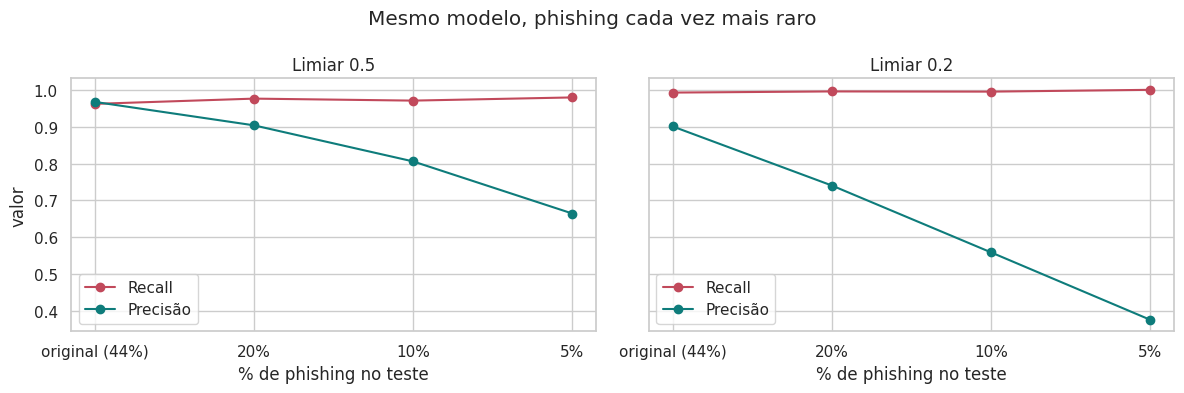

In [19]:
# Gráfico: precisão e recall conforme o phishing fica raro (limiar 0.5 e 0.2)
t = tabela_alt1.reset_index()
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, lim in enumerate([0.5, 0.2]):
    d = t[t['Limiar'] == lim]
    ax[i].plot(d['% phishing'], d['Recall'], 'o-', label='Recall', color='#C1495B')
    ax[i].plot(d['% phishing'], d['Precisão'], 'o-', label='Precisão', color='#0E7C7B')
    ax[i].set_title(f'Limiar {lim}'); ax[i].set_xlabel('% de phishing no teste'); ax[i].legend()
ax[0].set_ylabel('valor')
plt.suptitle('Mesmo modelo, phishing cada vez mais raro'); plt.tight_layout(); plt.show()

In [20]:
# Robustez: com 5% sobram só ~97 phishings no teste, então o sorteio importa.
# Repetimos o sorteio 20 vezes e olhamos média ± desvio.
res = []
for s in range(20):
    Xt, yt = reduzir_phishing(X_test, y_test, 0.05, seed=s)
    proba = rf.predict_proba(Xt)[:, 1]
    for lim in [0.5, 0.2]:
        res.append({'Limiar': lim, **avaliar(yt, proba, lim)})
robustez = (pd.DataFrame(res)
            .groupby('Limiar')[['Recall', 'Precisão', 'F1', 'PR-AUC', 'FP']]
            .agg(['mean', 'std']).round(3))
display(robustez)

Recall        Precisão            F1        PR-AUC           FP     
         mean    std     mean    std   mean    std   mean   std   mean  std
Limiar                                                                     
0.2     0.991  0.009    0.374  0.002  0.543  0.004   0.96  0.01  161.0  0.0
0.5     0.959  0.019    0.660  0.004  0.782  0.009   0.96  0.01   48.0  0.0

### 15.2 Alteração 2 — Treinar TAMBÉM com phishing raro e testar `class_weight`
Na Alteração 1 o modelo aprendeu com 44% de phishing. Em produção, a base de treino coletada também seria desbalanceada. Aqui o **treino** e o **teste** têm 5% de phishing, e comparamos o Random Forest **sem** compensação de classes (`class_weight=None`) e **com** compensação (`class_weight='balanced'`, que dá mais peso a cada exemplo de phishing).

In [21]:
X_train_r, y_train_r = reduzir_phishing(X_train, y_train, 0.05)
X_test_r,  y_test_r  = reduzir_phishing(X_test,  y_test,  0.05)
print(f'Treino: {len(y_train_r)} sites, {y_train_r.sum()} phishing ({y_train_r.mean():.1%})')
print(f'Teste : {len(y_test_r)} sites, {y_test_r.sum()} phishing ({y_test_r.mean():.1%})')

linhas = []
for cw in [None, 'balanced']:
    m = RandomForestClassifier(n_estimators=150, class_weight=cw,
                               n_jobs=-1, random_state=RANDOM_SEED)
    m.fit(X_train_r, y_train_r)
    proba = m.predict_proba(X_test_r)[:, 1]
    for lim in [0.5, 0.2]:
        linhas.append({'class_weight': str(cw), 'Limiar': lim, **avaliar(y_test_r, proba, lim)})

# Referência: modelo original (treinado com 44%) no MESMO teste de 5% (TESTE OOS)
proba_orig = rf.predict_proba(X_test_r)[:, 1]
for lim in [0.5, 0.2]:
    linhas.append({'class_weight': 'rf original (treino 44%)', 'Limiar': lim,
                   **avaliar(y_test_r, proba_orig, lim)})

tabela_alt2 = pd.DataFrame(linhas).set_index(['class_weight', 'Limiar'])
display(tabela_alt2.round(3))

Treino: 4536 sites, 226 phishing (5.0%)
Teste : 1944 sites, 97 phishing (5.0%)


Phishing no teste  TP  FN   FP  Recall  \
class_weight             Limiar                                           
None                     0.5                    97  69  28    1   0.711   
                         0.2                    97  84  13   29   0.866   
balanced                 0.5                    97  71  26    2   0.732   
                         0.2                    97  85  12   30   0.876   
rf original (treino 44%) 0.5                    97  95   2   48   0.979   
                         0.2                    97  97   0  161   1.000   

                                 Precisão     F1  Acurácia  PR-AUC  \
class_weight             Limiar                                      
None                     0.5        0.986  0.826     0.985   0.920   
                         0.2        0.743  0.800     0.978   0.920   
balanced                 0.5        0.973  0.835     0.986   0.921   
                         0.2        0.739  0.802     0.978   0.921   
rf original (treino 44%) 0.5        0.664  0.792     0.974   0.975   
                         0.2        0.376  0.546     0.917   0.975   

                                 Alarmes falsos por alerta  
class_weight             Limiar                             
None                     0.5                         0.014  
                         0.2                         0.257  
balanced                 0.5                         0.027  
                         0.2                         0.261  
rf original (treino 44%) 0.5                         0.336  
                         0.2                         0.624

## 16. Experimento AV1 — Mudança do Algoritmo

**Problema:** o Random Forest tem 150 árvores votando, o que o torna uma **caixa-preta**. Num SOC, quando um site é bloqueado, o analista precisa explicar **por quê**, tanto para liberar um falso positivo quanto para documentar um incidente. Além disso, um filtro de URLs precisa responder rápido.

**Alteração:** comparar o Random Forest com dois algoritmos simples e explicáveis já estudados:
- **Árvore de Decisão** (`max_depth=5`): vira um conjunto de regras "se... então" legíveis.
- **Regressão Logística**: cada feature recebe um peso; dá para ver o que empurra para phishing.

**Hipótese:** os modelos simples perdem um pouco de detecção (recall/PR-AUC), mas ganham em explicabilidade e velocidade. A pergunta é **quanto** se perde.

In [22]:
import time
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression

modelos = {
    'Random Forest (original)': RandomForestClassifier(n_estimators=150, class_weight='balanced',
                                                       n_jobs=-1, random_state=RANDOM_SEED),
    'Árvore de Decisão (depth de 5)': DecisionTreeClassifier(max_depth=5, class_weight='balanced',
                                                          random_state=RANDOM_SEED),
    'Regressão Logística': LogisticRegression(max_iter=1000, class_weight='balanced'),
}

linhas = []
for nome, m in modelos.items():
    t0 = time.perf_counter(); m.fit(X_train, y_train); t_treino = time.perf_counter() - t0
    t0 = time.perf_counter(); proba = m.predict_proba(X_test)[:, 1]; t_pred = time.perf_counter() - t0
    f1_cv = cross_val_score(m, X, y, cv=cv, scoring='f1').mean()    # Mesma validação cruzada da seção 11
    proba_r = m.predict_proba(X_test_r)[:, 1]                       # Teste com 5% de phishing (seção 15)
    # OBS: O primeiro teste é OOS, já o segundo usa o teste original
    for lim in [0.5, 0.2]:
        linhas.append({'Modelo': nome, 'Limiar': lim, 'Teste': 'original (44%)',
                       **avaliar(y_test, proba, lim), 'F1 (CV 5 dobras)': f1_cv,
                       'Treino (s)': t_treino, 'Previsão (ms/1000 URLs)': 1000 * t_pred / len(X_test) * 1000})
        linhas.append({'Modelo': nome, 'Limiar': lim, 'Teste': '5% phishing',
                       **avaliar(y_test_r, proba_r, lim)})

tabela_alt3 = pd.DataFrame(linhas).set_index(['Teste', 'Modelo', 'Limiar']).sort_index()
cols = ['TP', 'FN', 'FP', 'Recall', 'Precisão', 'F1', 'PR-AUC', 'F1 (CV 5 dobras)',
        'Treino (s)', 'Previsão (ms/1000 URLs)']
display(tabela_alt3[cols].round(3))

TP   FN   FP  Recall  \
Teste          Modelo                         Limiar                           
5% phishing    Random Forest (original)       0.2       97    0  161   1.000   
                                              0.5       95    2   48   0.979   
               Regressão Logística            0.2       96    1  332   0.990   
                                              0.5       89    8  138   0.918   
               Árvore de Decisão (depth de 5) 0.2       97    0  475   1.000   
                                              0.5       89    8   75   0.918   
original (44%) Random Forest (original)       0.2     1459   11  161   0.993   
                                              0.5     1414   56   48   0.962   
               Regressão Logística            0.2     1425   45  332   0.969   
                                              0.5     1351  119  138   0.919   
               Árvore de Decisão (depth de 5) 0.2     1454   16  475   0.989   
                                              0.5     1295  175   75   0.881   

                                                      Precisão     F1  PR-AUC  \
Teste          Modelo                         Limiar                            
5% phishing    Random Forest (original)       0.2        0.376  0.546   0.975   
                                              0.5        0.664  0.792   0.975   
               Regressão Logística            0.2        0.224  0.366   0.853   
                                              0.5        0.392  0.549   0.853   
               Árvore de Decisão (depth de 5) 0.2        0.170  0.290   0.849   
                                              0.5        0.543  0.682   0.849   
original (44%) Random Forest (original)       0.2        0.901  0.944   0.995   
                                              0.5        0.967  0.965   0.995   
               Regressão Logística            0.2        0.811  0.883   0.976   
                                              0.5        0.907  0.913   0.976   
               Árvore de Decisão (depth de 5) 0.2        0.754  0.856   0.969   
                                              0.5        0.945  0.912   0.969   

                                                      F1 (CV 5 dobras)  \
Teste          Modelo                         Limiar                     
5% phishing    Random Forest (original)       0.2                  NaN   
                                              0.5                  NaN   
               Regressão Logística            0.2                  NaN   
                                              0.5                  NaN   
               Árvore de Decisão (depth de 5) 0.2                  NaN   
                                              0.5                  NaN   
original (44%) Random Forest (original)       0.2                0.966   
                                              0.5                0.966   
               Regressão Logística            0.2                0.918   
                                              0.5                0.918   
               Árvore de Decisão (depth de 5) 0.2                0.906   
                                              0.5                0.906   

                                                      Treino (s)  \
Teste          Modelo                         Limiar               
5% phishing    Random Forest (original)       0.2            NaN   
                                              0.5            NaN   
               Regressão Logística            0.2            NaN   
                                              0.5            NaN   
               Árvore de Decisão (depth de 5) 0.2            NaN   
                                              0.5            NaN   
original (44%) Random Forest (original)       0.2          0.744   
                                              0.5          0.744   
               Regressão Logística            0.2          0.051   
               

,Nº de regras (folhas),FN,FP,Recall,Precisão,F1,PR-AUC
max_depth,,,,,,,
2,4,132,172,0.910,0.886,0.898,0.921
3,7,132,165,0.910,0.890,0.900,0.948
5,22,175,75,0.881,0.945,0.912,0.969
10,189,53,135,0.964,0.913,0.938,0.979
50,523,65,64,0.956,0.956,0.956,0.953


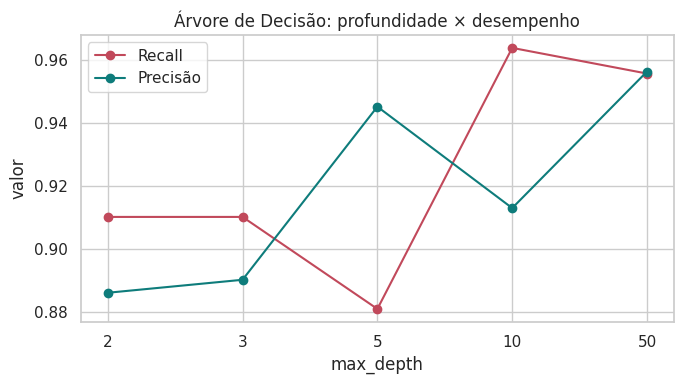

In [23]:
# Variando a profundidade da árvore: mais profunda = mais precisa, porém menos legível - (teoricamente)
linhas = []
for prof in [2, 3, 5, 10, 50]:
    arv = DecisionTreeClassifier(max_depth=prof, class_weight='balanced', random_state=RANDOM_SEED)
    arv.fit(X_train, y_train)
    linhas.append({'max_depth': str(prof), 'Nº de regras (folhas)': arv.get_n_leaves(),
                   **avaliar(y_test, arv.predict_proba(X_test)[:, 1], 0.5)})
tabela_prof = pd.DataFrame(linhas).set_index('max_depth')
display(tabela_prof[['Nº de regras (folhas)', 'FN', 'FP', 'Recall', 'Precisão', 'F1', 'PR-AUC']].round(3))

t = tabela_prof.reset_index()
plt.figure(figsize=(7, 4))
plt.plot(t['max_depth'], t['Recall'], 'o-', label='Recall', color='#C1495B')
plt.plot(t['max_depth'], t['Precisão'], 'o-', label='Precisão', color='#0E7C7B')
plt.xlabel('max_depth'); plt.ylabel('valor'); plt.title('Árvore de Decisão: profundidade × desempenho')
plt.legend(); plt.tight_layout(); plt.show()

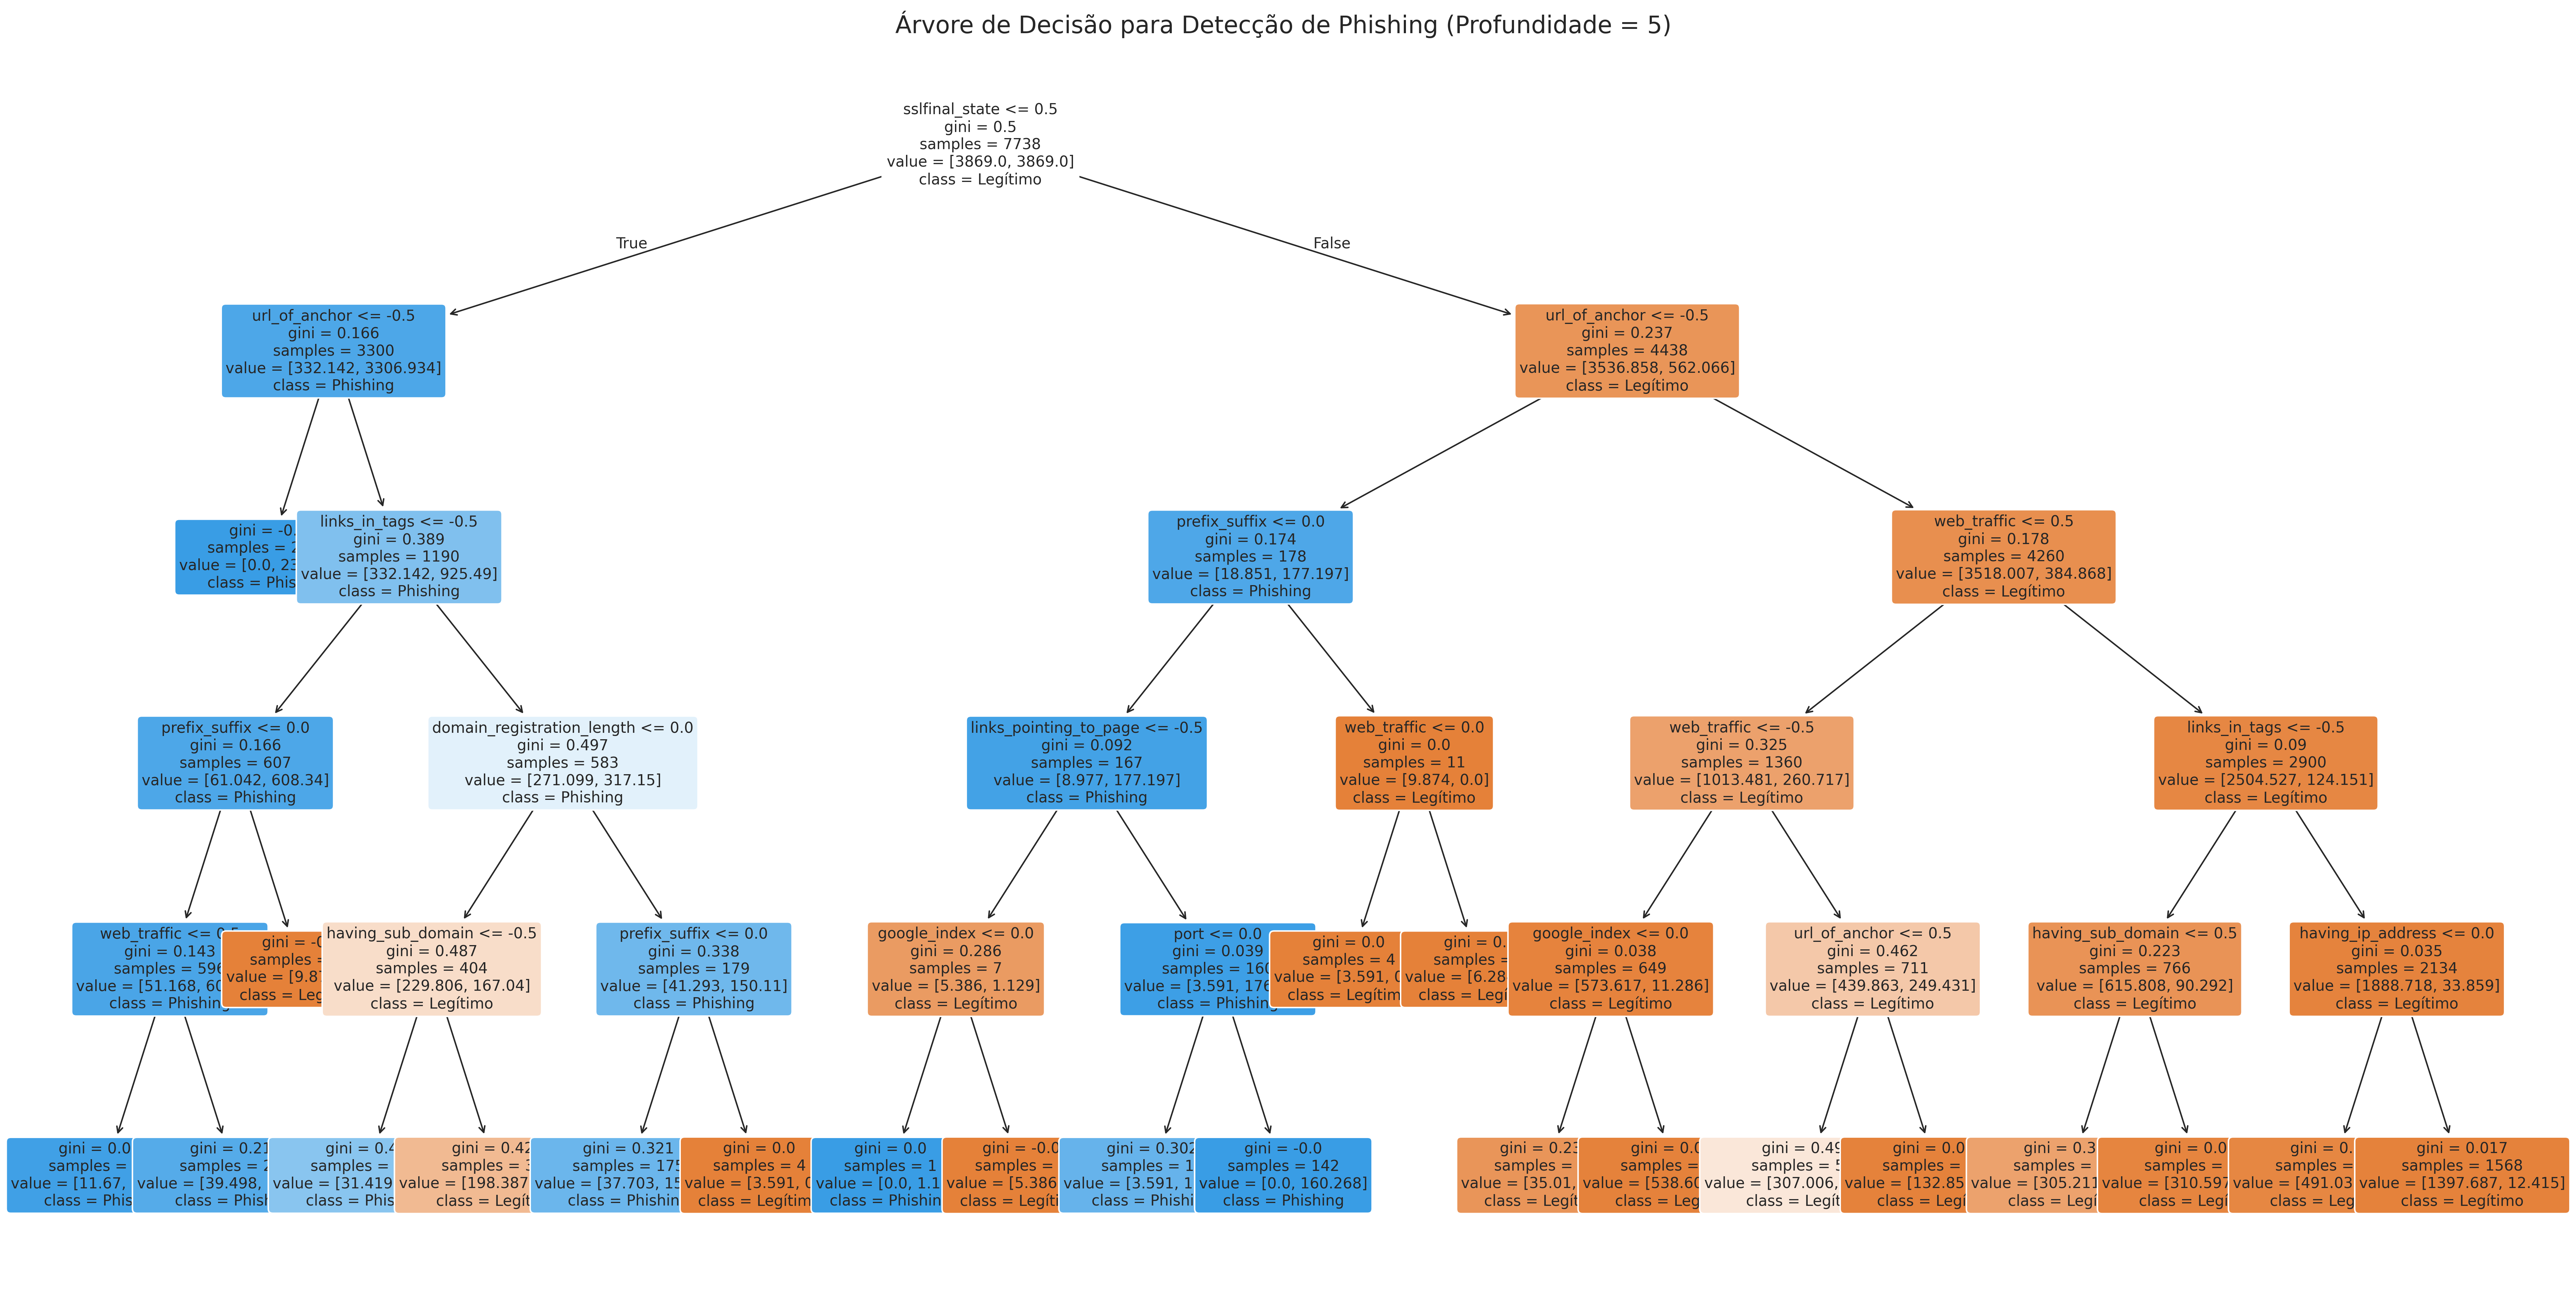

In [27]:
# Explicabilidade 1: Plotando a árvore de decisão graficamente
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

arv3 = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_SEED)
arv3.fit(X_train, y_train)

plt.figure(figsize=(30, 15), dpi=300)
plot_tree(arv3,
          feature_names=list(X.columns),
          class_names=['Legítimo', 'Phishing'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Árvore de Decisão para Detecção de Phishing (Profundidade = 5)", fontsize=16)
plt.show()

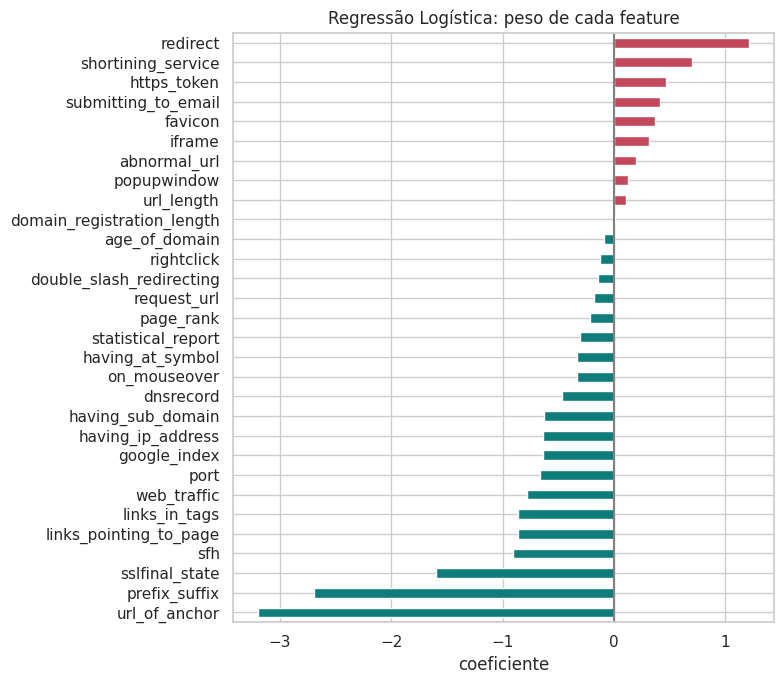

In [28]:
# Explicabilidade 2: pesos da Regressão Logística
# Peso positivo empurra para PHISHING e negativo empurra para LEGÍTIMO
pesos = pd.Series(modelos['Regressão Logística'].coef_[0], index=X.columns).sort_values()
plt.figure(figsize=(8, 7))
pesos.plot(kind='barh', color=np.where(pesos > 0, '#C1495B', '#0E7C7B'))
plt.axvline(0, color='gray'); plt.title('Regressão Logística: peso de cada feature')
plt.xlabel('coeficiente'); plt.tight_layout(); plt.show()